# ACS Dataset exploration

In [4]:
#!/usr/local/bin/python3.11 -m pip install geopandas contextily seaborn

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import seaborn as sns

# Setup

In [5]:
from src.acs_utils import (
    load_acs_csv,
    add_county_columns,
    aggregate_tracts_to_county_year,
)

#Load full tract-level ACS 
acs = load_acs_csv(
    "data/acs_bayarea_2009_2022_all_tables.csv"
)

# Add county identifiers 
acs = add_county_columns(acs)

# Aggregate tract → county-year 
county_year = aggregate_tracts_to_county_year(acs)

#Load HOLC Bay Area counties
holc = gpd.read_file("data/holc_bayarea.json")

gdf_counties = (
    holc[["GEOID", "NAME", "geometry"]]
    .dissolve(by=["GEOID", "NAME"])
    .reset_index()
)

#  Merge county geome
gdf_merged = gdf_counties.merge(
    county_year,
    left_on="GEOID",
    right_on="county_geoid",
    how="left",
)

# Sanity check (narrative belongs in notebook) 
display(
    gdf_merged[gdf_merged["year"] == 2022][
        ["GEOID", "NAME", "median_home_value", "pct_poc"]
    ].head()
)

/home/jovyan/final-group10/src/acs_utils.py:202: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,GEOID,NAME,median_home_value,pct_poc
13,06001,Alameda,9.894843e+05,0.707029
27,06013,Contra Costa,8.560677e+05,0.594244
41,06075,San Francisco,1.308964e+06,0.617055
55,06081,San Mateo,1.434872e+06,0.629811
69,06085,Santa Clara,1.296834e+06,0.708315


# Median home value across Bay Area (map)

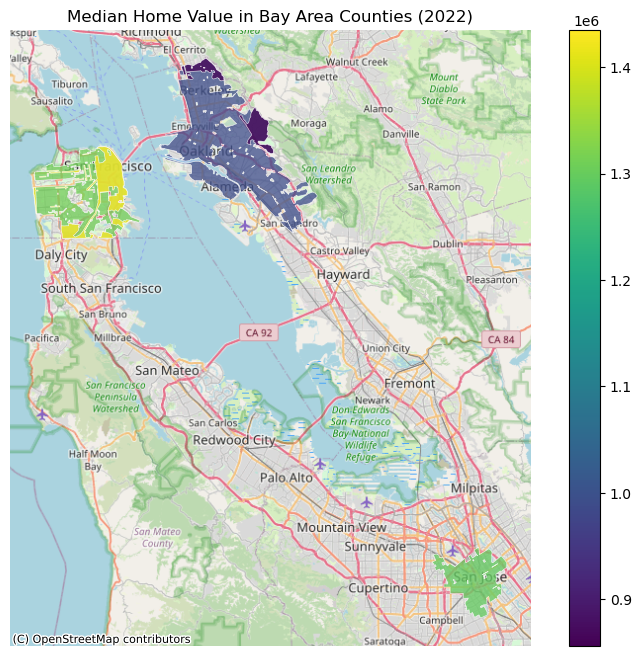

In [13]:
year = 2022
plot_data = (
    gdf_merged[gdf_merged["year"] == year]
    .dropna(subset=["geometry", "median_home_value"])
)

if plot_data.crs is None:
    plot_data = plot_data.set_crs("EPSG:4326")

plot_data_3857 = plot_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data_3857.plot(
    column="median_home_value",
    cmap="viridis",
    legend=True,
    ax=ax,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5,
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"Median Home Value in Bay Area Counties ({year})")
ax.axis("off")
plt.show()


The above figure shows the median home values in the Bay Area counties we are examining. We see clear differences in home values in the different counties, with San Francisco having the highest housing prices and the east bay having the lowest. San Francisco is a major economic hub, and places like San Jose or Santa Clara have a close proximity to Silicon Valley, another major economic hub. This shows a clear trend: the counties which are closest to larger development hubs have clearly higher property values than other counties in the Bay Area. We can see that, based on geographic location in the area, median home prices will clearly vary. 

# % People of Color (POC) distribution (map)

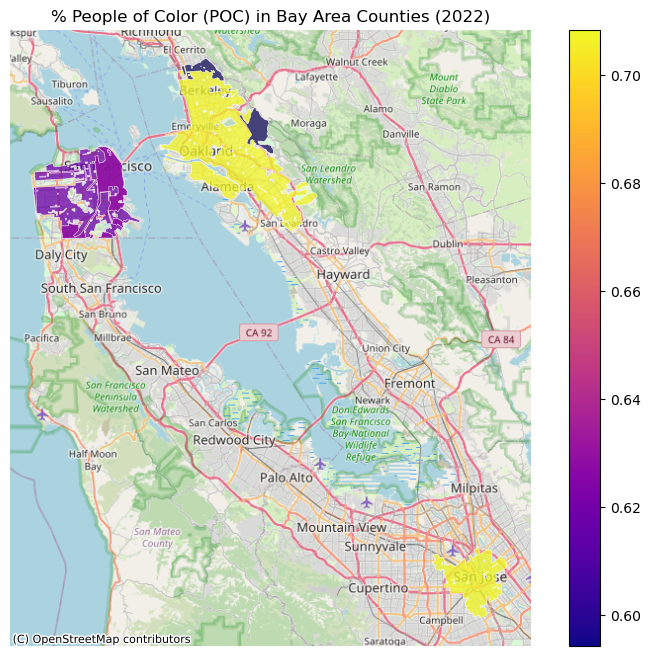

In [14]:
plot_data = (
    gdf_merged[gdf_merged["year"] == year]
    .dropna(subset=["geometry", "pct_poc"])
)

if plot_data.crs is None:
    plot_data = plot_data.set_crs("EPSG:4326")

plot_data_3857 = plot_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

plot_data_3857.plot(
    column="pct_poc",
    cmap="plasma",
    legend=True,
    ax=ax,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"% People of Color (POC) in Bay Area Counties ({year})")
ax.axis("off")

plt.show()

In this map depicting the racial diversity in the same Bay Area counties, we see another notable difference: the Santa Clara region and, more clearly, the East Bay, have much higher racial diversity in comparison to the more homogeneous San Francisco. Prior to the fair housing act, historical redlining policies which limited where communities of color could buy homes had a clear effect on the racial makeup of the counties. Communities of color are more concentrated in counties that are relatively more affordable, but often farther from economic centers, increasing commute burdens and reducing access to opportunities like homeownership. Viewing both of the prior maps together, we can see a geographic relationship between race and housing wealth, with higher housing cost areas tending to be less diverse, while more diverse communities are concentrated in lower cost counties. This provides a strong visual of how historical inequality and policies continue to hold an effect over who can afford to live in more opportunity rich parts of the Bay Area.

# Line plot: Median home value over time by county

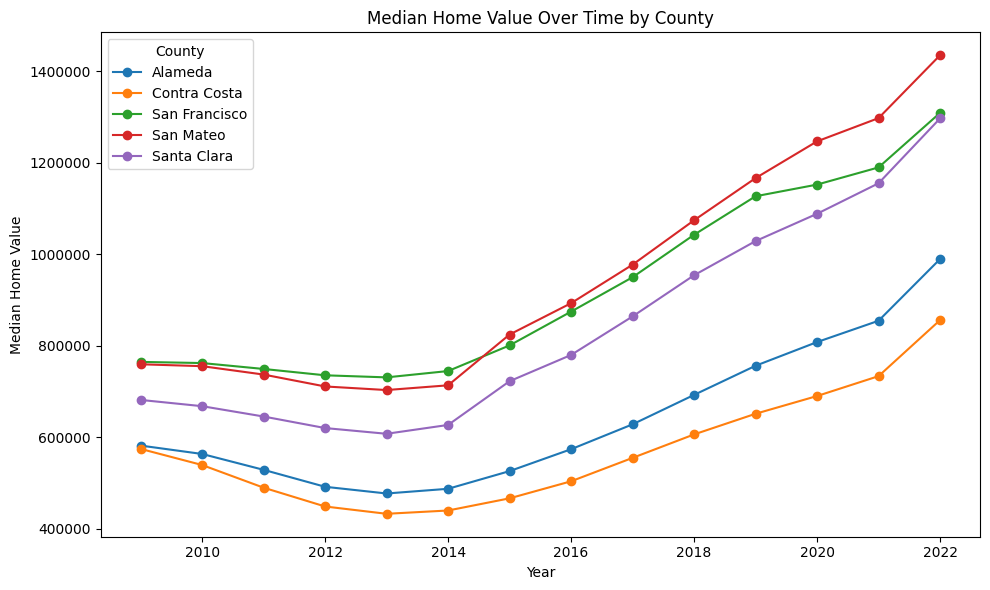

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure ordering by year
data = county_year.sort_values(["county_name", "year"])

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["median_home_value"], marker="o", label=county)

ax.set_title("Median Home Value Over Time by County")
ax.set_xlabel("Year")
ax.set_ylabel("Median Home Value")
ax.ticklabel_format(axis="y", style="plain") 
ax.legend(title="County")
plt.tight_layout()
plt.show()

Looking at this chart on its own, it shows a shared regional housing cycle with uneven outcomes across counties. All five Bay Area counties experienced a decline in median home values from 2009 to 2013 together, which makes sense when paired with the knowledge of the housing market crash just prior. While prices rise together after that point, the counties maintain consistency in ranking, with San Mateo, San Francisco, and Santa Clara at the top and Alameda and Contra Costa at the bottom. The gap between higher and lower priced counties widens over time, showing that appreciation occurred faster in already expensive markets. The chart illustrates that, although housing values increased in all counties shown, growth was not the same, leading to increasing difference in home values across the Bay Area. Taken together, the maps and the chart show that housing inequality in the Bay Area is clearly geographic. Counties closest to major job centers (San Mateo, San Francisco, and Santa Clara) started with higher home values and experienced faster appreciation, which resulted in greater housing wealth gain. In contrast, Alameda and Contra Costa counties, which have higher proportions of People of Color, remained more affordable, but saw slower growth. The pairing of racial composition with price trends highlights how historical and structural factors have limited access to high growth housing markets for more diverse communities, reinforcing racial and economic disparities through uneven opportunities for homeownership. 

#  Line plot: Median income over time by county

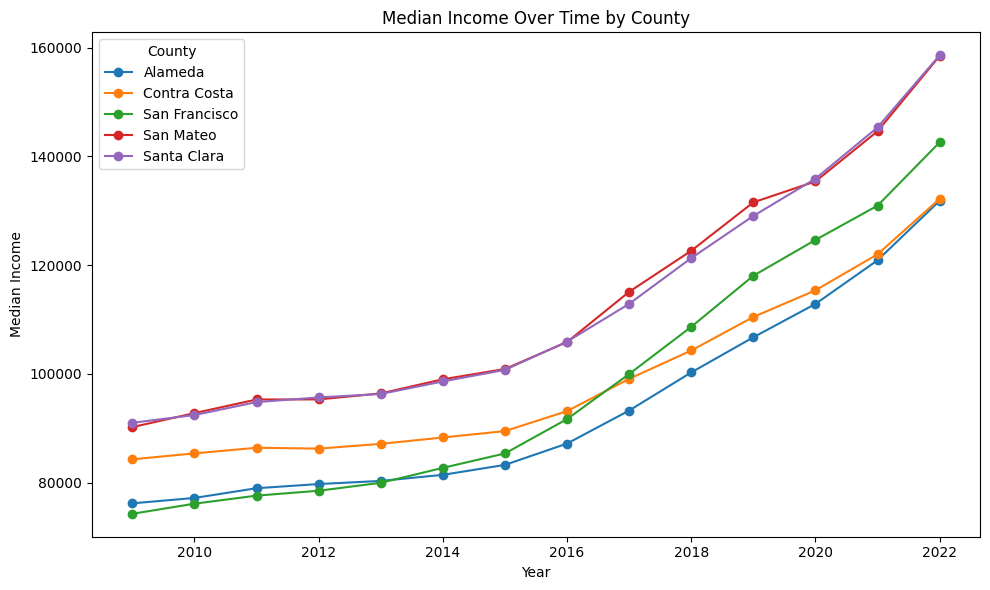

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))

data = county_year.sort_values(["county_name", "year"])

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["median_income"], marker="o", label=county)

ax.set_title("Median Income Over Time by County")
ax.set_xlabel("Year")
ax.set_ylabel("Median Income")
ax.ticklabel_format(axis="y", style="plain")
ax.legend(title="County")
plt.tight_layout()
plt.show()

Unlike home values, the income lines in this chart are closer together, suggesting that income inequality between counties grows more moderately than housing costs. Overall, the chart indicates that while earnings increased significantly across the region, and the rise in incomes was more similar between counties than the rise in home prices, implying increasing pressure on affordability even as incomes improved. 

#  %POC change over time

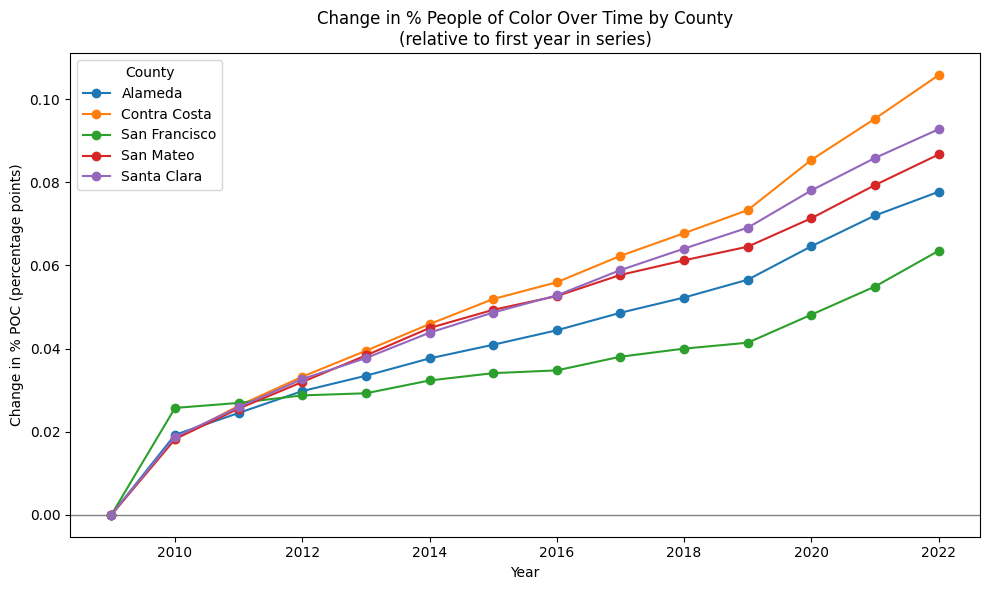

In [59]:
data = county_year.sort_values(["county_name", "year"]).copy()

# Compute change from first year per county
data["pct_poc_change"] = data.groupby("county_name")["pct_poc"].transform(
    lambda s: s - s.iloc[0]
)

fig, ax = plt.subplots(figsize=(10, 6))

for county, group in data.groupby("county_name"):
    ax.plot(group["year"], group["pct_poc_change"], marker="o", label=county)

ax.set_title("Change in % People of Color Over Time by County\n(relative to first year in series)")
ax.set_xlabel("Year")
ax.set_ylabel("Change in % POC (percentage points)")
ax.axhline(0, color="gray", linewidth=1)
ax.legend(title="County")
plt.tight_layout()
plt.show()

This chart indicates that, despite differences in pace, the Bay Area as a whole has become more diverse over time, regardless of specific county. The consistent upward trends imply demographic shifts driven by migration and generational change as opposed to changes in individual counties.

#  Scatterplot: %POC vs Median home value

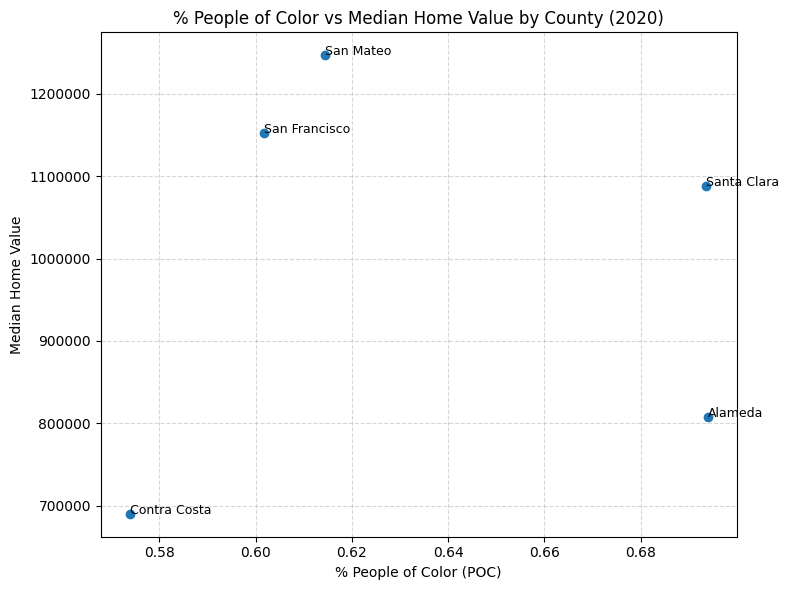

In [60]:
scatter_data = county_year[county_year["year"] == year].dropna(
    subset=["pct_poc", "median_home_value"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(scatter_data["pct_poc"], scatter_data["median_home_value"])

# Add county labels next to points
for _, row in scatter_data.iterrows():
    ax.text(row["pct_poc"],
            row["median_home_value"],
            row["county_name"],
            fontsize=9)

ax.set_title(f"% People of Color vs Median Home Value by County ({year})")
ax.set_xlabel("% People of Color (POC)")
ax.set_ylabel("Median Home Value")
ax.ticklabel_format(axis="y", style="plain")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Regression Line

In [61]:
cols = [
    "pct_poc",              # % people of color
    "median_home_value"     # property value
]

sub = acs[cols].copy()

# drop missing or invalid values
sub = sub.dropna()

In [62]:
from scipy.stats import pearsonr, spearmanr

x = sub["pct_poc"]
y = sub["median_home_value"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r: {pearson_r:.3f} (p={pearson_p:.3e})")
print(f"Spearman: {spearman_r:.3f} (p={spearman_p:.3e})")

Pearson r: -0.401 (p=0.000e+00)
Spearman: -0.441 (p=0.000e+00)


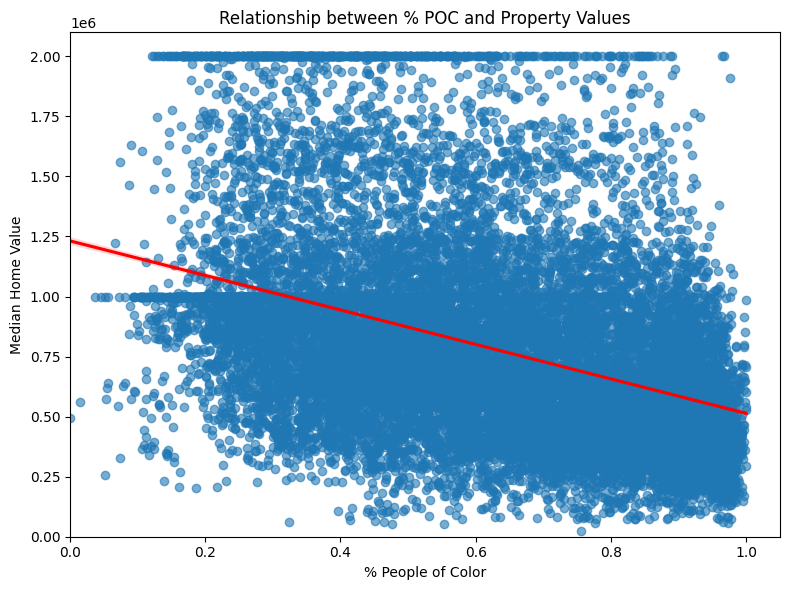

In [63]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sub,
    x="pct_poc",
    y="median_home_value",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Relationship between % POC and Property Values")
plt.xlabel("% People of Color")
plt.ylabel("Median Home Value")
plt.xlim(0,1.05)
plt.ylim(0,2100000)
plt.tight_layout()
plt.show()

These two charts illustrate the relationship between racial composition and housing values at different levels of detail. The county scatter plot shows that Bay Area counties with higher percentages of People of Color generally have lower median home values, while counties with lower POC shares tend to have higher home values. Contra Costa and Alameda have both higher POC percentages and lower median home values, where San Mateo, San Francisco, and Santa Clara combine lower POC shares with substantially higher housing costs. The pattern suggests a negative association between racial diversity and home values at the county scale. The scatter plot with the regression line reinforces this pattern at the census tract level. While there is significant spread when looking at each of the census tracts in comparison to each other, showing variation in home values, the downward trend line shows a clear negative correlation; as median home values increase, the percentage of People of Color tends to increase in the area. This suggests that the pattern reflects a broader structural relationship. 